In [2]:
import numpy as np

In [3]:
matrix = np.ones((5, 5))
matrix[1:-1, 1:-1] = 0
matrix

array([[1., 1., 1., 1., 1.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 0., 1.],
       [1., 1., 1., 1., 1.]])

In [4]:
np.random.seed(42)
random_data = np.random.randn(100, 3)

mean = random_data.mean(axis=0)
std = random_data.std(axis=0)

normalized = (random_data - mean) / std

normalized.mean(axis=0), normalized.std(axis=0)

(array([-2.60902411e-17,  1.55431223e-17, -8.88178420e-18]),
 array([1., 1., 1.]))

In [5]:
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1

X_bias = np.c_[np.ones(X.shape[0]), X]

theta_hat = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ y

theta_hat

array([-0.01035573,  2.51756955, -1.19800274,  3.72573182])

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

n_students = 200

data = {
    "student_id": range(1000, 1000 + n_students),
    "major": np.random.choice(
        ["Computer Science", "Business Administration", "Engineering", "Economics"],
        n_students,
    ),
    "year": np.random.choice([1, 2, 3, 4], n_students),
    # IMPORTANT: required column
    "exam_score": np.random.normal(75, 10, n_students).clip(0, 100),
    "assignments_completed": np.random.randint(0, 11, n_students),
    "hours_studied": np.random.normal(15, 5, n_students).clip(1, 40),
}

df = pd.DataFrame(data)

# Add missing values (as required by lab)
df.loc[np.random.choice(n_students, 10), "exam_score"] = np.nan
df.loc[np.random.choice(n_students, 5), "hours_studied"] = np.nan

df.head()

,student_id,major,year,exam_score,assignments_completed,hours_studied
0,1000,Engineering,3,68.199753,10,NaN
1,1001,Economics,4,77.322537,9,12.204873
2,1002,Computer Science,3,77.930725,9,7.829556
3,1003,Engineering,1,67.856486,2,14.042336
4,1004,Engineering,4,93.657745,6,15.287370


In [14]:
df.isnull().sum()

student_id                0
major                     0
year                      0
exam_score               10
assignments_completed     0
hours_studied             5
dtype: int64

In [ ]:
df["exam_score"] = df["exam_score"].fillna(
    df.groupby("major")["exam_score"].transform("mean")
)

df["hours_studied"] = df["hours_studied"].fillna(
    df.groupby("year")["hours_studied"].median()
)

df.isnull().sum()

student_id               0
major                    0
year                     0
exam_score               0
assignments_completed    0
hours_studied            5
dtype: int64

In [ ]:
df.groupby("major")["exam_score"].mean()

major
Business Administration    74.683689
Computer Science           76.425184
Economics                  75.503150
Engineering                75.406509
Name: exam_score, dtype: float64

In [ ]:
df.groupby("major")["exam_score"].mean().idxmax()

'Computer Science'

In [ ]:
df["hours_studied"].corr(df["exam_score"])

np.float64(-0.05679962900286857)

In [ ]:
def performance(score):
    if score > 90:
        return "Excellent"
    elif score >= 80:
        return "Good"
    elif score >= 70:
        return "Average"
    else:
        return "Needs Improvement"


df["performance"] = df["exam_score"].apply(performance)
df.head()

,student_id,major,year,exam_score,assignments_completed,hours_studied,performance
0,1000,Engineering,3,68.199753,10,NaN,Needs Improvement
1,1001,Economics,4,77.322537,9,12.204873,Average
2,1002,Computer Science,3,77.930725,9,7.829556,Average
3,1003,Engineering,1,67.856486,2,14.042336,Needs Improvement
4,1004,Engineering,4,93.657745,6,15.287370,Excellent


In [ ]:
df.groupby(["major", "year"]).agg(
    count=("student_id", "count"),
    avg_score=("exam_score", "mean"),
    avg_hours=("hours_studied", "mean"),
)

count  avg_score  avg_hours
major                   year                             
Business Administration 1        11  74.053167  19.001215
                        2         9  81.226714  12.031242
                        3        10  72.017537  15.175871
                        4        16  73.103066  17.551879
Computer Science        1        12  77.098194  13.039480
                        2         7  76.155936  13.851868
                        3         9  72.347626  15.039892
                        4        18  78.119997  16.275541
Economics               1        13  76.570059  12.677806
                        2        12  74.899613  13.426372
                        3        14  80.178476  14.521865
                        4        15  70.697689  14.253944
Engineering             1        13  77.828686  13.489911
                        2        12  73.277734  14.616778
                        3        17  73.134319  14.210446
                        4        12  78.130194  15.550491

In [ ]:
df.sort_values("exam_score", ascending=False).head(5)

,student_id,major,year,exam_score,assignments_completed,hours_studied,performance
57,1057,Computer Science,2,100.000000,8,11.870035,Excellent
27,1027,Business Administration,2,100.000000,4,2.716265,Excellent
68,1068,Economics,3,98.146586,1,11.379991,Excellent
82,1082,Computer Science,2,96.439441,0,7.378547,Excellent
132,1132,Computer Science,4,96.330334,10,17.546891,Excellent


In [ ]:
df.pivot_table(values="exam_score", index="major", columns="year", aggfunc="mean")

year,1,2,3,4
major,,,,
Business Administration,74.053167,81.226714,72.017537,73.103066
Computer Science,77.098194,76.155936,72.347626,78.119997
Economics,76.570059,74.899613,80.178476,70.697689
Engineering,77.828686,73.277734,73.134319,78.130194


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

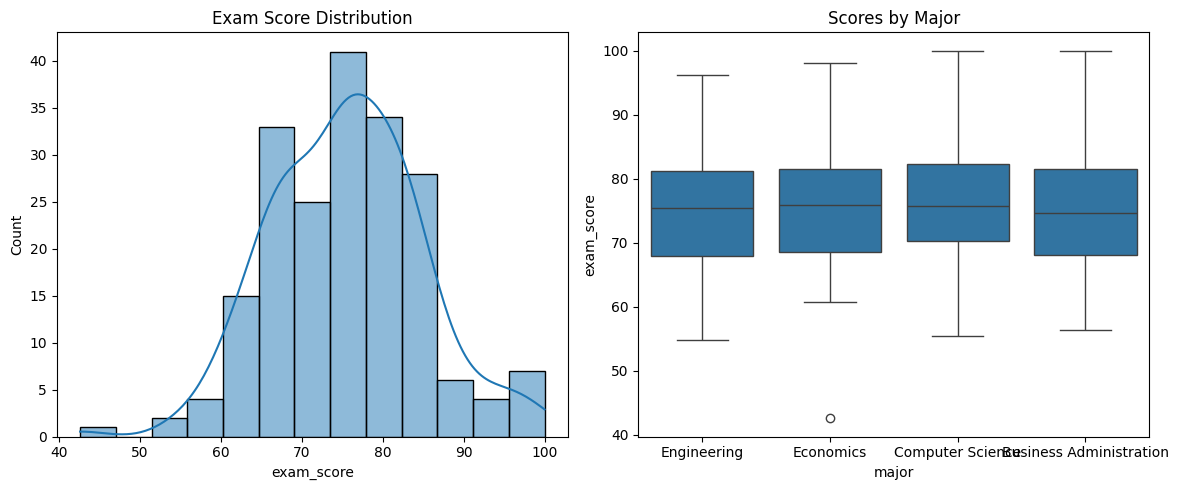

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df["exam_score"], kde=True, ax=ax[0])
ax[0].set_title("Exam Score Distribution")

sns.boxplot(data=df, x="major", y="exam_score", ax=ax[1])
ax[1].set_title("Scores by Major")

plt.tight_layout()
plt.show()

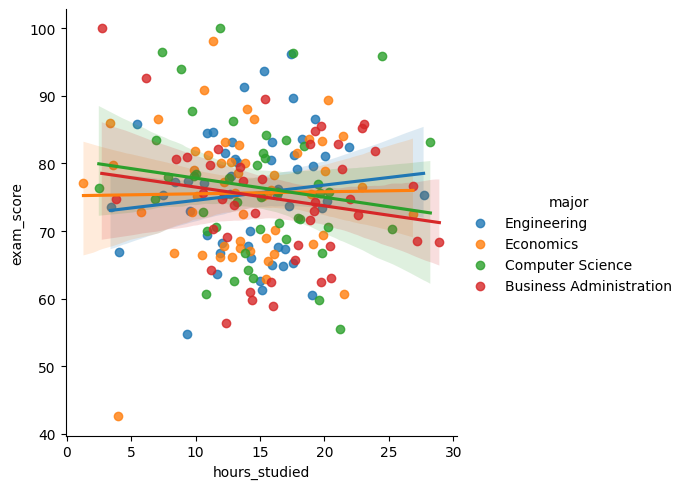

In [ ]:
sns.lmplot(data=df, x="hours_studied", y="exam_score", hue="major")
plt.show()

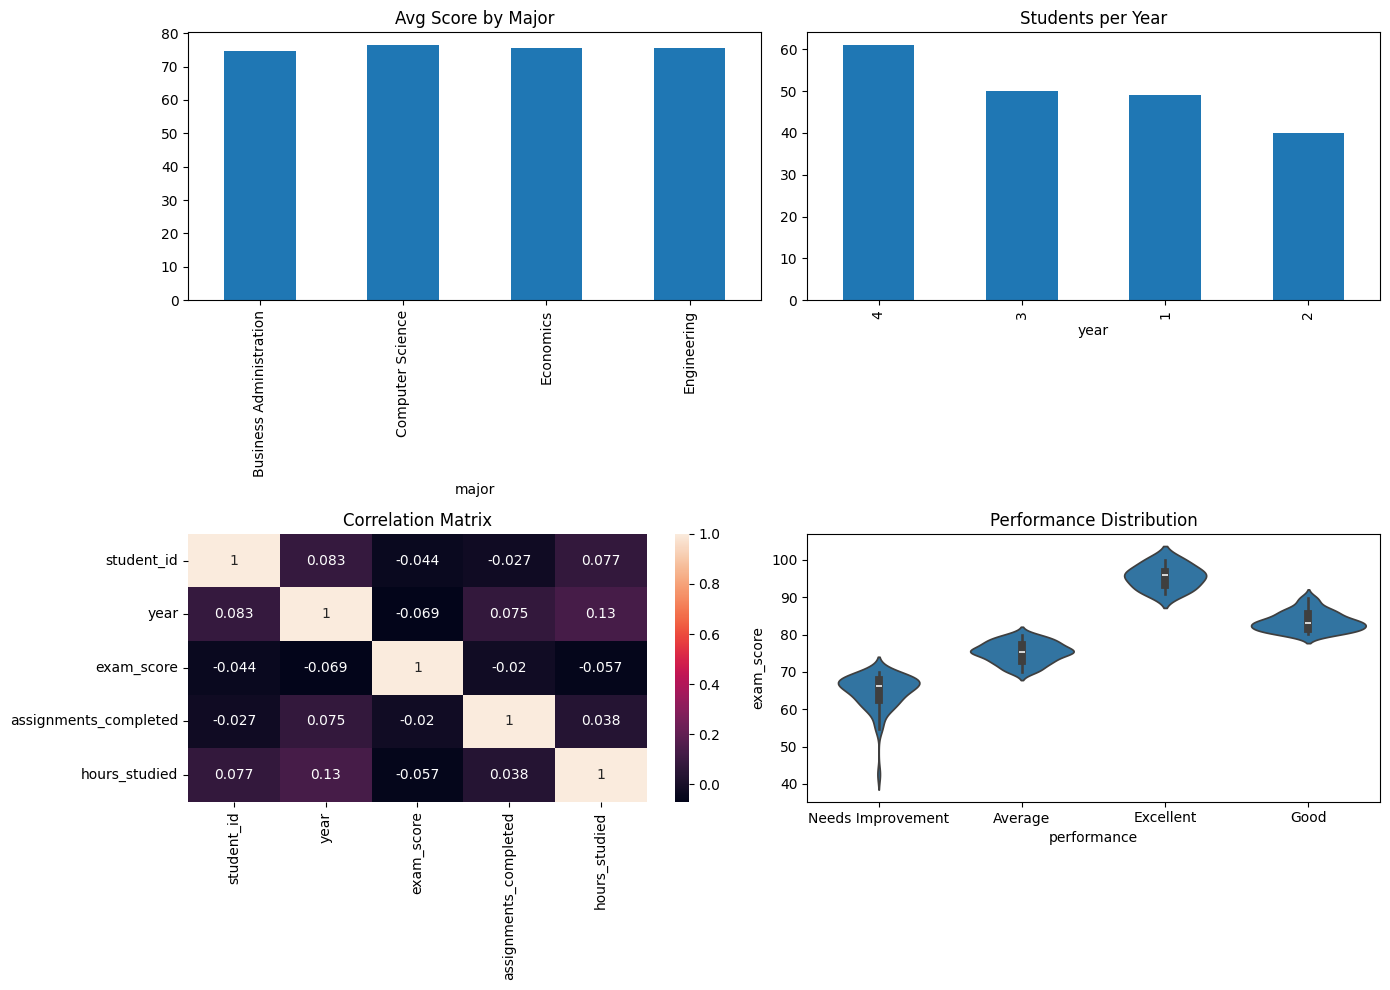

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

df.groupby("major")["exam_score"].mean().plot(kind="bar", ax=ax[0, 0])
ax[0, 0].set_title("Avg Score by Major")

df["year"].value_counts().plot(kind="bar", ax=ax[0, 1])
ax[0, 1].set_title("Students per Year")

sns.heatmap(df.corr(numeric_only=True), annot=True, ax=ax[1, 0])
ax[1, 0].set_title("Correlation Matrix")

sns.violinplot(data=df, x="performance", y="exam_score", ax=ax[1, 1])
ax[1, 1].set_title("Performance Distribution")

plt.tight_layout()
plt.show()

In [ ]:
np.random.seed(42)

n = 500

customers = pd.DataFrame(
    {
        "age": np.random.randint(18, 70, n),
        "income": np.random.normal(50000, 20000, n).clip(15000, 150000),
        "purchase_frequency": np.random.poisson(5, n),
        "avg_purchase_value": np.random.normal(100, 30, n).clip(10, 500),
    }
)

In [ ]:
max_freq = customers["purchase_frequency"].max()

customers["churn_risk"] = 1 - (customers["purchase_frequency"] / max_freq)

customers["clv"] = (
    customers["purchase_frequency"]
    * customers["avg_purchase_value"]
    * (1 + customers["churn_risk"])
)

In [ ]:
customers["age_group"] = pd.cut(
    customers["age"],
    bins=[18, 25, 35, 50, 70],
    labels=["18-25", "26-35", "36-50", "51-70"],
)

In [ ]:
customers.groupby("age_group")["clv"].mean()

age_group
18-25    704.492597
26-35    747.738562
36-50    732.796612
51-70    762.693498
Name: clv, dtype: float64

In [ ]:
customers[customers["clv"] >= customers["clv"].quantile(0.9)].head()

,age,income,purchase_frequency,avg_purchase_value,churn_risk,clv,age_group
6,38,58876.388563,10,110.331527,0.166667,1287.201143,36-50
9,40,48809.492879,10,110.228581,0.166667,1286.000108,36-50
19,41,21282.756976,8,119.651218,0.333333,1276.279663,36-50
24,38,53981.193911,8,120.320786,0.333333,1283.421714,36-50
57,64,45956.146951,7,135.470585,0.416667,1343.416638,51-70


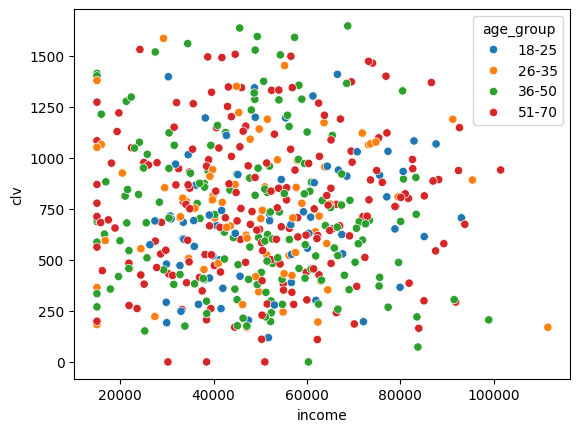

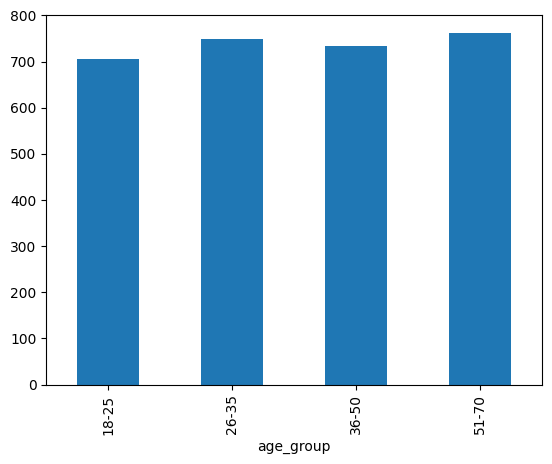

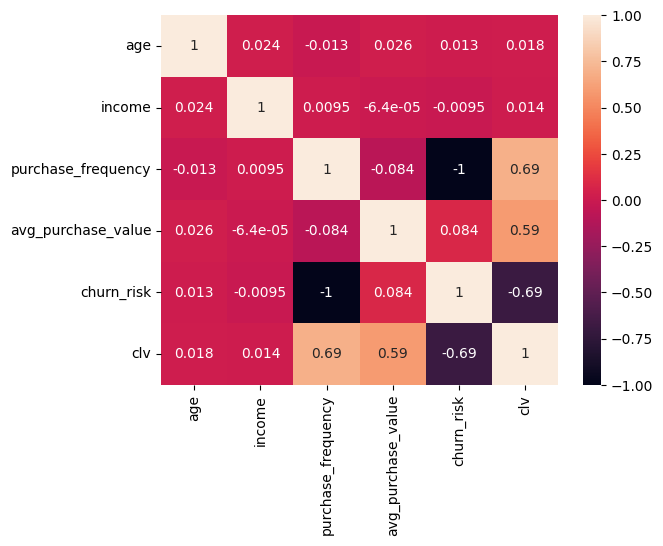

In [ ]:
sns.scatterplot(data=customers, x="income", y="clv", hue="age_group")
plt.show()

customers.groupby("age_group")["clv"].mean().plot(kind="bar")
plt.show()

sns.heatmap(customers.corr(numeric_only=True), annot=True)
plt.show()